# PCB Drilling TSP: Full Pipeline Demo

This notebook demonstrates the complete lifecycle of a single problem instance:
1. **Generation:** Create a realistic PCB geometry (JSON).
2. **Preprocessing:** Compute Cost Matrix & Clusters (DAT).
3. **Optimization:** Run the C++ Hierarchical Solver.
4. **Visualization:** Plot the resulting tour with gradients.

In [ ]:
import sys
import os
import subprocess
import time
from pathlib import Path

current_dir = Path(os.getcwd())
project_root = current_dir.parent  
scripts_dir = project_root / "scripts"
sys.path.append(str(scripts_dir))

from generate_board import BoardGenerator
from build_cost_matrix import MatrixGenerator
from compute_clusters import ClusterGenerator
from plot_board import plot_board_file
from plot_tour import plot_tour, load_tour_file

DATA_DIR = project_root / "notebooks" / "data"
CONFIG_PATH = scripts_dir / "config" / "drill_specs.yaml"
SOLVER_BIN = project_root / "bin" / "demo_solver" 

INSTANCE_NAME = "demo_instance"

import shutil
if DATA_DIR.exists(): shutil.rmtree(DATA_DIR)
DATA_DIR.mkdir(parents=True, exist_ok=True)

### 1. Instance Generation
We generate a structured board

Processing config idx=demo_instance -> Generating 1 instances...
Generated: /home/lcallegari/Desktop/sohard/notebooks/data/demo_instance_n100_d1e87418.json


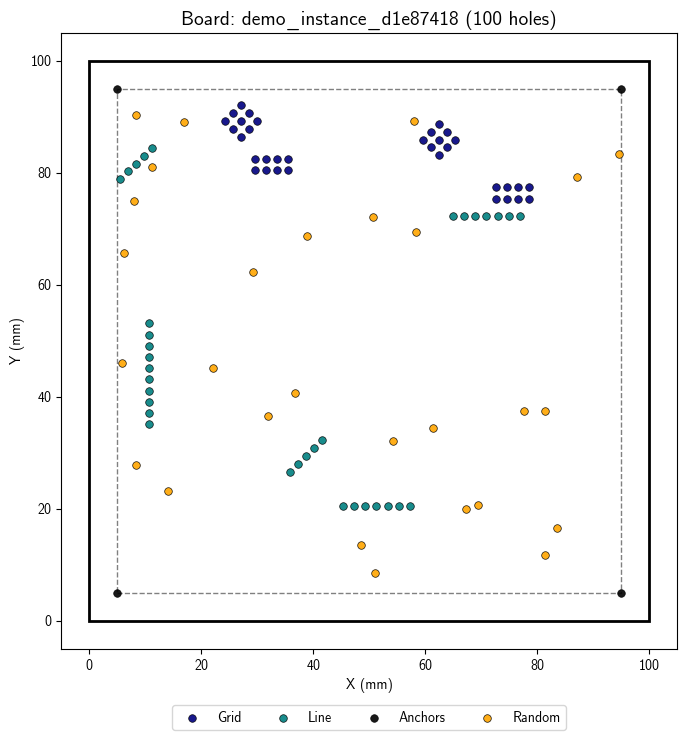

In [2]:
config = {
    "idx": INSTANCE_NAME,
    "metadata": {
        "n_instances": 1,
        "unit": "mm",
        "target_dir": ""
    },
    "board": {
        "width": 100.0, "height": 100.0,
        "margin": 5.0, "min_spacing": 0.5,
        "mounting_holes": {"enabled": True, "corners": True}
    },
    "components": [
        {"type": "grid", "params": {"repeat": 2, "rows": 3, "cols": 3, "row_spacing": 2, "col_spacing": 2, "angle_deg": 45}},
        {"type": "grid", "params": {"repeat": 2, "rows": 2, "cols": 4, "row_spacing": 2, "col_spacing": 2, "angle_deg": 0}},
        {"type": "line", "params": {"n_holes": 10, "spacing": 2.0, "angle_deg": 90}},
        {"type": "line", "params": {"repeat": 2, "n_holes": 5, "spacing": 2.0, "angle_deg": 45}},
        {"type": "line", "params": {"repeat": 2, "n_holes": 7, "spacing": 2.0, "angle_deg": 0}},
        {"type": "rand", "params": {"n_holes": 28}} # Fill the rest
    ]
}

gen = BoardGenerator(output_dir_override=DATA_DIR)
gen.process_config(config)

json_file = list(DATA_DIR.glob("*.json"))[0]
print(f"Generated: {json_file}")

plot_board_file(json_file, show=True, show_ids=False, marker_size=30)

### 2. Pre-Processing
Compute the Cost Matrix ($O(N^2)$) and K-Means Clusters.

In [3]:

matrix_gen = MatrixGenerator(CONFIG_PATH)
matrix_dat = json_file.with_suffix(".dat")
matrix_gen.process_file(json_file, matrix_dat)
print(f"Matrix saved to: {matrix_dat}")


cluster_gen = ClusterGenerator(CONFIG_PATH)
cluster_dat = json_file.with_name(json_file.stem + ".clusters")
cluster_gen.process_file(json_file, cluster_dat, k_method="elbow")
print(f"Clusters saved to: {cluster_dat}")

Loaded Drill Specs: Metric=L2, Vx=1.0, Vy=1.0
Matrix saved to: /home/lcallegari/Desktop/sohard/notebooks/data/demo_instance_n100_d1e87418.dat
Clusters saved to: /home/lcallegari/Desktop/sohard/notebooks/data/demo_instance_n100_d1e87418.clusters


Visualizing Clusters from: /home/lcallegari/Desktop/sohard/notebooks/data/demo_instance_n100_d1e87418.clusters


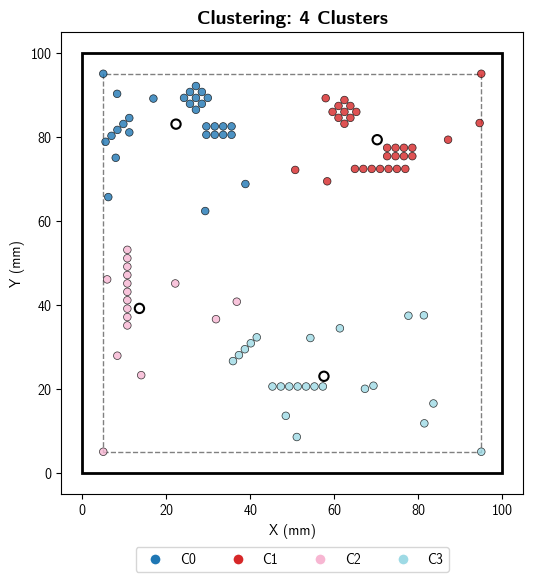

In [4]:
from plot_clusters import plot_clusters

if cluster_dat.exists():
    print(f"Visualizing Clusters from: {cluster_dat}")
    
    plot_clusters(
        json_path=json_file,
        clusters_path=cluster_dat,
        show=True,           
        save_path=None, 
        marker_size=30,   
    )
else:
    print("Error: Cluster file not found. Please check Step 2.")

### 3. Solver Execution
Calling the C++ binary as a subprocess.

In [5]:
tour_file = DATA_DIR / "tour.txt"

cmd = [
    str(SOLVER_BIN),
    str(matrix_dat),
    str(cluster_dat),
    str(tour_file)
]

print(f"Running: {' '.join(cmd)}")

start_time = time.time()
result = subprocess.run(cmd, capture_output=True, text=True)
elapsed = time.time() - start_time

if result.returncode == 0:
    print(f"Success! Solver finished in {elapsed:.4f}s")
    print("--- Solver Output ---")
    print(result.stdout)
else:
    print("Error running solver:")
    print(result.stderr)

Running: /home/lcallegari/Desktop/sohard/bin/demo_solver /home/lcallegari/Desktop/sohard/notebooks/data/demo_instance_n100_d1e87418.dat /home/lcallegari/Desktop/sohard/notebooks/data/demo_instance_n100_d1e87418.clusters /home/lcallegari/Desktop/sohard/notebooks/data/tour.txt
Success! Solver finished in 0.0126s
--- Solver Output ---
=== Loading Instance ===
Coords:      /home/lcallegari/Desktop/sohard/notebooks/data/demo_instance_n100_d1e87418.dat
Clusters:    /home/lcallegari/Desktop/sohard/notebooks/data/demo_instance_n100_d1e87418.clusters
Output:      /home/lcallegari/Desktop/sohard/notebooks/data/tour.txt

[2/4] Running Hierarchical (Sequential K=8)...
      -> Done. Cost: 618.6182

[3/4] Running Hierarchical (Parallel K=8)...
      -> Done. Cost: 618.6182

[4/4] Running Detailed Breakdown...

                                FINAL LEADERBOARD                               
Method                   Cost           Time (ms)      Gap
---------------------------------------------------

### 4. Visualization
Plotting the final optimized tour.

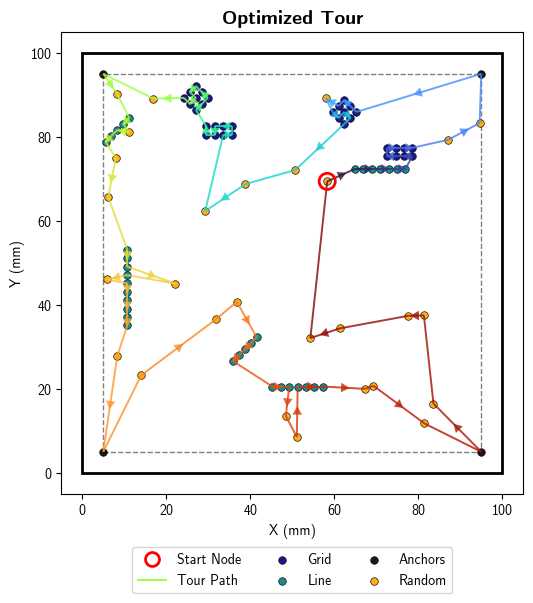

In [6]:
if tour_file.exists():
    tour = load_tour_file(tour_file)
    
    plot_tour(
        board_path=json_file,
        tour=tour,
        title_text=f"Optimized Tour",
        show=True,
        show_arrows=True,
        arrow_interval=2, 
        tour_cmap="turbo",
        marker_size=30,
    )
else:
    print("No tour file found. Did the solver fail?")